In [13]:
import pandas as pd

In [14]:
train_df = pd.read_csv("train.csv")
features_df = pd.read_csv("features.csv")
stores_df = pd.read_csv("stores.csv")

In [15]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [16]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [17]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [19]:
df=pd.merge(
    train_df,
    features_df,
    on=["Store","Date","IsHoliday"],
    how="left"
)

In [20]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [21]:
df=pd.merge(
    df,
    stores_df,
    on=["Store"],
    how="left"
)

In [22]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  str    
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), str(2)
memory usage: 48.6 MB


In [24]:
df = df.fillna(0) #handling missing columns

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

In [26]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


In [33]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,1,118221,2012,9,39,28
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,1,118221,2012,10,40,5
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,1,118221,2012,10,41,12
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,1,118221,2012,10,42,19
421569,45,98,2012-10-26,1076.80,False,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,1,118221,2012,10,43,26


In [34]:
df.shape

(421570, 20)

In [30]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le=LabelEncoder()
df["Type"]=le.fit_transform(df["Type"])

In [36]:
df.head(3)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,151315,2010,2,7,19


In [37]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
Year            0
Month           0
Week            0
Day             0
dtype: int64

In [38]:
X = df.drop(['Weekly_Sales', 'Date'], axis=1)
y = df['Weekly_Sales']

In [41]:
print(X.head())

   Store  Dept  IsHoliday  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1     1      False        42.31       2.572        0.0        0.0   
1      1     1       True        38.51       2.548        0.0        0.0   
2      1     1      False        39.93       2.514        0.0        0.0   
3      1     1      False        46.63       2.561        0.0        0.0   
4      1     1      False        46.50       2.625        0.0        0.0   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  Type    Size  \
0        0.0        0.0        0.0  211.096358         8.106     0  151315   
1        0.0        0.0        0.0  211.242170         8.106     0  151315   
2        0.0        0.0        0.0  211.289143         8.106     0  151315   
3        0.0        0.0        0.0  211.319643         8.106     0  151315   
4        0.0        0.0        0.0  211.350143         8.106     0  151315   

   Year  Month  Week  Day  
0  2010      2     5    5  
1  2010      2    

In [42]:
print(y.head())

0    24924.50
1    46039.49
2    41595.55
3    19403.54
4    21827.90
Name: Weekly_Sales, dtype: float64


In [59]:
df['Lag_1'] = (
    df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(1)
)

In [60]:
df['Rolling_Mean_4'] = (
    df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .transform(lambda x: x.rolling(4).mean())
)

In [61]:
df = df.dropna()

In [62]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [50]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 9.4 MB/s eta 0:00:11
   - -------------------------------------- 3.4/101.7 MB 9.2 MB/s eta 0:00:11
   -- ------------------------------------- 5.5/101.7 MB 9.3 MB/s eta 0:00:11
   --- ------------------------------------ 7.9/101.7 MB 9.4 MB/s eta 0:00:11
   --- ------------------------------------ 9.4/101.7 MB 9.0 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/101.7 MB 8.9 MB/s eta 0:00:11
   ---- ----------------------------------- 12.1/101.7 MB 8.5 MB/s eta 0:00:11
   ----- ---------------------------------- 13.1/101.7 MB 7.7 MB/s eta 0:00:12
   ----- ---------------------------------- 14.4/101.7 MB 7.6 MB/s eta 0:00:12
   ------ --------------------------------- 15.7/101.7 MB 7.2 MB/s eta 0:00:12
   ------ --------------------------------- 17.3/101.7 MB 7.2 MB/s eta 0:

In [63]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [64]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [65]:
predictions = model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5183.770702137582
RMSE: 9697.475641360117


In [56]:
pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.2 MB 9.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 9.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.4 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 7.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.1 MB 10.0 MB/s eta 0:00:01
   ------------------- -------------------- 3.4/7.1 MB 8.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.1 MB 8.6 MB/s eta 0:00:01
   -------------------------------- -

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

         Feature  Importance
1           Dept    0.336776
13          Size    0.245177
12          Type    0.141189
0          Store    0.063253
15         Month    0.043859
16          Week    0.041669
10           CPI    0.032676
2      IsHoliday    0.018351
11  Unemployment    0.018215
7      MarkDown3    0.014486
17           Day    0.011998
14          Year    0.007570
3    Temperature    0.006501
8      MarkDown4    0.005987
9      MarkDown5    0.003637
4     Fuel_Price    0.003226
5      MarkDown1    0.002760
6      MarkDown2    0.002669


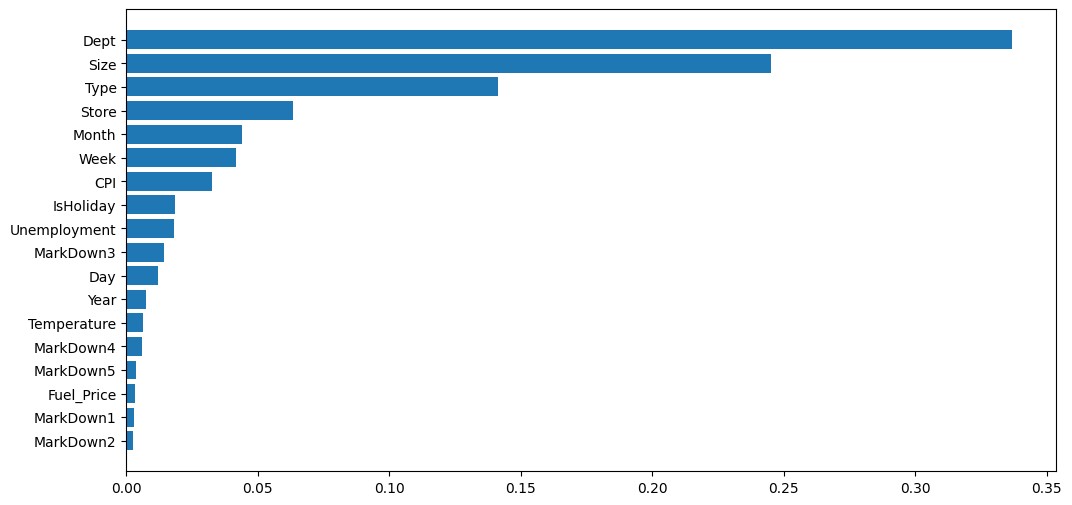

In [69]:
plt.figure(figsize=(12,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.gca().invert_yaxis()
plt.show()

In [70]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [71]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']